# Project: Investigate a Dataset - No-Show Appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This dataset, called "No-Show Appointments", has collected information from over 100,000 medical appointments in Brazil for the purpose of examining why so many people miss their doctor's appointments. The dataset contains many variables that we can examine:

**PatientID & AppointmentID**: This shows the patient ID and the appointment ID, per appointment. This is likely used for business purposes and not too relevant to our analysis, although it is possible there are particular patients that have a long history of no-shows.

**Gender**: The patient's gender.

**ScheduledDay**: When the patient set up their appointment.

**AppointmentDay**: The date of the appointment.

**Age**: The age of the patient.

**Neighborhood**: The location of the hospital.

**Scholarship**: Whether the patient is enrolled in Brasilian welfare programs, listed as binary.

**Hipertension**: Whether the patient has hypertension, listed as binary.

**Diabetes**: Whether the patient has diabetes, listed as binary.

**Alcoholism**: Whether the patient is an alcoholic, listed as binary.

**Handcap**: Whether the patient has a handicap, can be higher than 1.

**SMS_received**: Whether the patient got an SMS notification regarding their appointment, listed as binary.

**No-Show**: Whether the patient was a no-show or not, listed as No or Yes.

### Question(s) for Analysis

In this analysis, I aim to answer two key questions: whether SMS notifications change the rate of patient no-shows, and whether the presence or absence of illnesses is correlated with no-show behavior. Understanding these relationships will help us predict no-shows based on a patient’s number of illnesses and determine whether SMS notifications should be used more widely for appointment reminders.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Test to see if this stays here
# REMEMBER - THIS STAYS HERE


<a id='wrangling'></a>
## Data Wrangling

### General Properties

First, we will import the database using pandas.

In [2]:
ns = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')

Here, we have an initial look at the database structure. We will now look for missing or errant data.

In [4]:
ns.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


This gives us the total number of rows in the dataset.

In [5]:
ns.shape[0]

110527

In [6]:
ns.nunique()

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

Based on the information we see here, it appears our database looks rather clean.
The data shows that all of our AppointmentIDs are unique, and overall, all of the values look perfectly feasible.

In [7]:
ns.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Looking at our data further, the data looks reasonable, but there is an age that is minus 1, which we will need to prune.

In [8]:
ns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Based on our high-level view of the dataset, it seems that this dataset is actually very clean, although there is at least one outlier in the age column, because it is not possible for someone to be aged -1. We also want to convert the No-show column into binary values so that we can analyze this easier. We will fix this in the next section: Data Cleaning.



### Data Cleaning

Next, we will take steps in order to correct any outliers in the age column, and convert the No-show column into binary values.
 

In [9]:
# Here, we remove any ages under 0. It is theoretically possible for us to have patients that are 0, so we should not remove these values, but anything under 0 is definitely wrong.
ns = ns[ns['Age'] >= 0]

Let's now take a look and see if that removed the outliers.

In [11]:
ns.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029
std,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Perfect! Now the `-1` age is gone, and the `min` is `0` as it should be.

Let's now rewrite the No-show column to be binary, so that we can do more advanced analysis on it.

In [12]:
ns['No-show'] = ns['No-show'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_6442/2081349496.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ns['No-show'] = ns['No-show'].replace({'Yes': 1, 'No': 0})


And now let's take a look to see if that worked.

In [13]:
ns.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,0
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,0
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,0
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,0
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,0
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,1
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,1
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,0
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,0


As you can see, this matches our `head(10)` function we called earlier in this analysis, but now, no-shows are coded as `1` instead of `Yes`.

<a id='eda'></a>
## Exploratory Data Analysis

Now that we've cleaned our data, we're ready to move on to exploration.


### Research Question 1: Do SMS notifications change the rate of no-shows?

Because we will be working a lot with the mean of the `No-show` column based on outside characteristics, we will register a function to make our analysis' code easier to read.

In [14]:
def no_show_mean(filter):
    return ns.query(filter)['No-show'].mean()

Now that the function is in place, we will analyze whether SMS notifications change the rate of patient no-shows. First, let's examine whether there is a difference in no-show rates between patients who did and did not receive SMS notifications.

In [15]:
sms_percent = no_show_mean('SMS_received == 1')
nosms_percent = no_show_mean('SMS_received == 0')
print(sms_percent)
print(nosms_percent)

0.27574544839637
0.16703533926762965


Interestingly, those who received an SMS notification have significantly higher no-shows (27.6%) than people that did not (16.7%). Let's create a simple pie chart to show the large difference between these two cases.

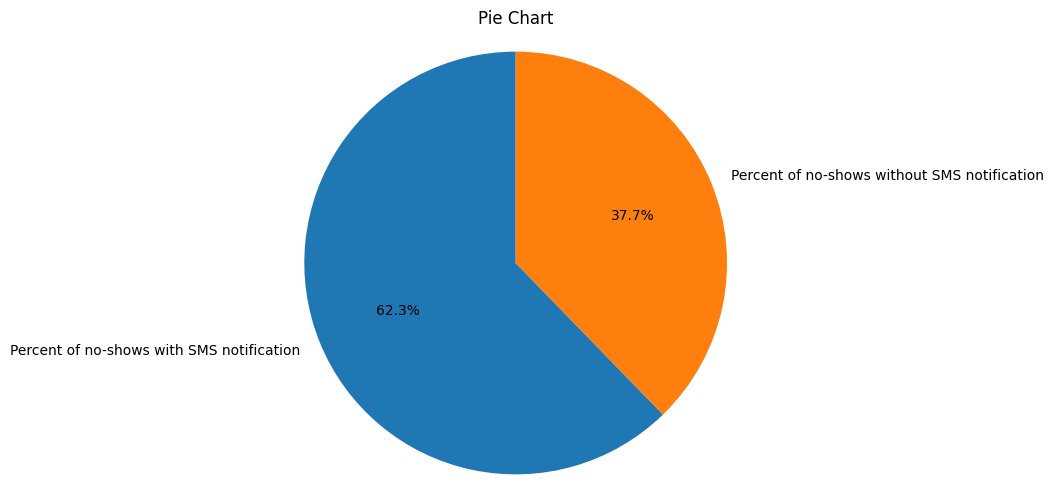

In [16]:
labels = ['Percent of no-shows with SMS notification', 'Percent of no-shows without SMS notification']
sizes = [sms_percent, nosms_percent] 


plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  
plt.title('Pie Chart')
plt.show()

Next, let's create a graph to visualize this data and to see how big the sample size is.

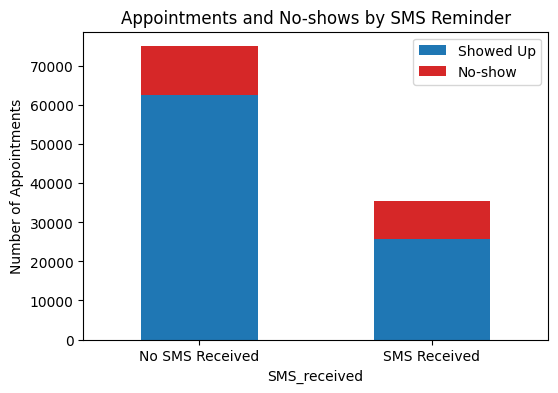

In [17]:
summary = (
    ns.groupby('SMS_received')['No-show']
      .value_counts()
      .unstack(fill_value=0)
)

summary.plot(
    kind='bar',
    stacked=True,
    color=['tab:blue', 'tab:red'],
    figsize=(6,4)
)

plt.xticks([0,1], ['No SMS Received', 'SMS Received'], rotation=0)
plt.ylabel('Number of Appointments')
plt.title('Appointments and No-shows by SMS Reminder')
plt.legend(['Showed Up', 'No-show'])
plt.show()

As you can see, there are far more no-shows in the SMS Received group proportionally, but we have significantly less data. Let's run a logistic regression to see if the difference is statistically significant.

In [19]:
import statsmodels.api as sm
y = ns['No-show']
X = sm.add_constant(ns['SMS_received'])
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.495371
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                No-show   No. Observations:               110526
Model:                          Logit   Df Residuals:                   110524
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Dec 2025   Pseudo R-squ.:                 0.01531
Time:                        17:29:09   Log-Likelihood:                -54751.
converged:                       True   LL-Null:                       -55603.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.6068      0.010   -164.185      0.000      -1.626      -1.588
SMS_received     0.6411

Based on this, because the p-value is less than `0.0001`, we can conclude that this is a strong correlation with high statistical significance. **However, this does not necessarily mean that we should stop notifying people using SMS**, because it is possible that there are hidden influences in our data. For example, what if people that got SMS notifications are mostly young, and tend to be more busy, leading to higher no-shows? This is something that should be further analyzed in future research.

### Research Question 2: Does the type or number of personal illnesses affect no-shows?

Next, we will analyze whether particular illnesses, or the number of them, affect no-shows. First, let's start with hypertension and see if there are any noticeable differences.

In [48]:
ht_percent = no_show_mean('Hipertension == 1')
noht_percent = no_show_mean('Hipertension == 0')
print(ht_percent)
print(noht_percent)

0.17301958625751113
0.2090391659622429


From our first query, we do see that the amount of no-shows is slightly less in patients with hypertension, which makes a lot of logical sense. Let's continue through other illnesses to see if there is a larger correlation.

In [49]:
db_percent = no_show_mean('Diabetes == 1')
nodb_percent = no_show_mean('Diabetes == 0')
print(db_percent)
print(nodb_percent)

0.18003273322422259
0.20363023112991432


In [50]:
hc_percent = no_show_mean('Handcap == 1')
nohc_percent = no_show_mean('Handcap == 0')
print(hc_percent)
print(nohc_percent)

0.1792360430950049
0.20235489680011082


In [51]:
al_percent = no_show_mean('Alcoholism == 1')
noal_percent = no_show_mean('Alcoholism == 0')
print(al_percent)
print(noal_percent)

0.20148809523809524
0.20194837915010358


It seems as though other ailments follow the same general pattern, except non-alcoholics and alcoholics behave almost identically. Let's put this on a chart to visualize the results.

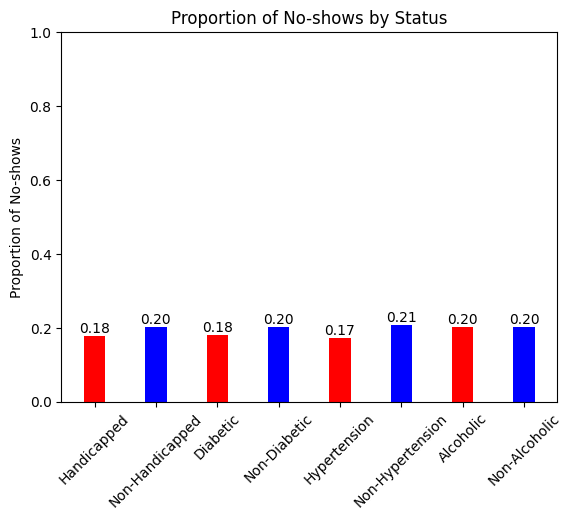

In [52]:
labels = ['Handicapped', 'Non-Handicapped', 'Diabetic', 'Non-Diabetic', 'Hypertension', 'Non-Hypertension', 'Alcoholic', 'Non-Alcoholic']
percentages = [hc_percent, nohc_percent, db_percent, nodb_percent, ht_percent, noht_percent, al_percent, noal_percent]

x = np.arange(len(labels)) 
width = 0.35
fig, ax = plt.subplots()
bars = ax.bar(x, percentages, width, color=['red', 'blue'])
ax.set_ylabel('Proportion of No-shows')
ax.set_title('Proportion of No-shows by Status')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()


Now, let's look at how multiple illnesses affect no-show rates. To do this, we're going to add up all of the illness columns and create a new column called `TotalIllnesses` which will store the number of illnesses the patient has. Keep in mind, the patient can have multiple handicaps.

In [53]:
ns['TotalIllnesses'] = ns[['Handcap', 'Diabetes', 'Alcoholism', 'Hipertension']].sum(axis=1)

Now, let's see how this new variable affects no-show rates.

In [54]:
ti_percent = ns.groupby('TotalIllnesses')['No-show'].mean()
print(ti_percent)

TotalIllnesses
0    0.209276
1    0.179472
2    0.176913
3    0.169872
4    0.190476
5    1.000000
Name: No-show, dtype: float64


It looks like there was a single person with a value of `5` (meaning they had multiple handicaps) that turned out to be a no-show. Since that is an outlier in the dataset and we don't have enough data, let's exclude that and create a line chart to show our results.

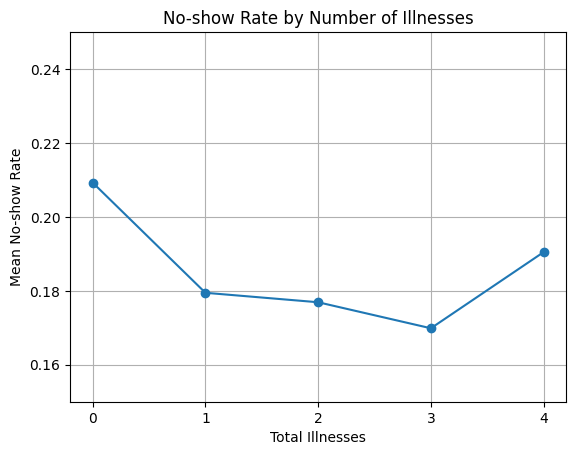

In [55]:
ns = ns[ns['TotalIllnesses'] != 5]
ti_percent = ns.groupby('TotalIllnesses')['No-show'].mean()

plt.plot(ti_percent.index, ti_percent.values, marker='o')
plt.xlabel('Total Illnesses')
plt.ylabel('Mean No-show Rate')
plt.title('No-show Rate by Number of Illnesses')
plt.xticks(ti_percent.index)
plt.ylim(0.15,0.25)
plt.grid(True)

plt.show()

This is quite interesting: people with no registered illnesses have higher no-show rates than people with a registered illness, with the no-show rate steadily declining from people that have 1 to 3 illnesses, but people that have 4 illnesses have significantly more no-shows than people with 1-3 illnesses. There could be many reasons for this: it is possible that people with 4 illnesses have more difficulty in getting to their appointments, or that they are less responsible with their health. 

<a id='conclusions'></a>
## Conclusions

Based on our analysis of this study, we have discovered three major findings:

### **1.** There is a statistically significant correlation between SMS notifications and higher no-show rates. 

Our analysis showed that patients that received SMS notifications were much more likely to be a no-show compared to those who did not get SMS notifications. Despite this strong correlation, it is not likely that the hospitals should discard SMS notifications; it is more probable that the SMS notifications are mostly sent out to a certain age group or neighborhood that has a significantly higher no-show rate.

### **2.** Patients with registered illnesses generally have lower no-show rates than those with none, but alcoholics are an exception to this.

Patients with one or more registered illnesses tended to keep their appointments more reliably than their counterparts, with the exception of alcoholics. This may be caused by their struggles with the addiction or it could be a commentary on their life habits, but it requires further research.

### **3.** No-show rates steadily decline for people that have 1 to 3 illnesses, but people with 4 illnesses have higher no-show rates.

There is also a clear trend showing that patients with 1 to 3 illnesses are progressively more likely to attend their appointments, suggesting that having multiple health concerns motivates patients to avoid no-shows. However, oddly enough, patients with 4 illnesses had a significantly higher no-show rate than people with 1-3 illnesses. This could be due to the complexity of managing multiple conditions or the difficulty of getting to appointments.

While all of the data and analysis here is compeletely valid, one major limitation of this analysis is that we have compared relatively few variables in our dataset. It is possible that one hospital is a major outlier, skewing our statistics, or that younger people have a much higher rate of no-shows but they also have fewer registered illnesses, again skewing our results. In the future, it would be important to do a cluster analysis or conduct machine learning on the dataset to learn more about how each variable in the dataset relates to one another, to help us produce actionable insights and ultimately reduce no-shows. 

In [56]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 506343 bytes to Investigate_a_Dataset.html


# Thank you for reading my analysis, I hope you enjoyed it!